# Lending Club Credit Risk Analysis
## Notebook 3 — Feature Engineering, Modeling, and Policy Simulation

**Author:** Jeffrey Symons  
**Date:** July 2026  
**Purpose:** Build and evaluate credit risk models, simulate policy thresholds.

### What this notebook does:
1. Feature engineering — encoding, null imputation
2. Train/test split (80/20 stratified)
3. Three model comparison — Logistic Regression, Random Forest, XGBoost
4. Feature importance analysis
5. Policy simulation — threshold analysis with dollar quantification
6. Policy validation — term and DTI rescue analysis
7. Export for Tableau

### Key finding:
Removing Lending Club's grade and interest rate (circular features derived from
the same bureau attributes) costs only 0.009 AUC — confirming the raw bureau
data carries independent predictive signal equivalent to their proprietary system.

## 1. Imports and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 100)

df = pd.read_parquet('lending_club_v2_correlated.parquet',
                     engine='fastparquet')

print('Shape:', df.shape)
print('Memory:', df.memory_usage(deep=True).sum() / 1e6, 'MB')

Shape: (1217422, 39)
Memory: 136.353047 MB


## 2. Feature Engineering

### Why grade and int_rate are excluded:
Lending Club assigns grade and interest rate using the same bureau attributes
used as model features. Including them means modeling their model — not building
an independent credit risk assessment. Removing them costs only 0.009 AUC.

In [20]:
# Drop columns not suitable as model features
drop_cols = [
    'loan_status',        # source of target variable
    'issue_d',            # date — credit_age_months captures the signal
    'earliest_cr_line',   # date — used to engineer credit_age_months
    'grade',              # LC derived — circular (based on same bureau attrs)
    'sub_grade',          # LC derived — circular
    'int_rate',           # LC derived from grade — circular
    'verification_status' # confounding variable — proxy for grade
]

df_model = df.drop(columns=drop_cols)
print('Shape after dropping non-features:', df_model.shape)
print('Columns:', df_model.columns.tolist())

Shape after dropping non-features: (1217422, 32)
Columns: ['acc_open_past_24mths', 'addr_state', 'annual_inc', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'emp_length', 'funded_amnt', 'home_ownership', 'inq_last_6mths', 'mo_sin_old_il_acct', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_last_delinq', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_actv_rev_tl', 'num_bc_tl', 'num_tl_90g_dpd_24m', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'term', 'total_rev_hi_lim', 'credit_age_months', 'default', 'ever_delinq', 'dti_bucket']


In [21]:
# Ordinal encoding — variables with natural risk order
emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10, 'n/a': -1
}

# Pull from original df where category values are intact
df_model['emp_length'] = df['emp_length'].map(emp_length_map).astype('float64')

print(df_model['emp_length'].value_counts())
print('Nulls:', df_model['emp_length'].isnull().sum())

emp_length
10.00    407592
2.00     109575
3.00      96901
0.00      92915
1.00      79726
5.00      75227
4.00      71569
-1.00     70274
6.00      56295
8.00      56039
7.00      54447
9.00      46862
Name: count, dtype: int64
Nulls: 0


In [22]:
# Dummy encoding — nominal categories with no natural order
df_model = pd.get_dummies(
    df_model,
    columns=['home_ownership', 'purpose', 'addr_state'],
    drop_first=True,  # avoid dummy variable trap
    dtype=int
)
print('Shape after encoding:', df_model.shape)

Shape after encoding: (1217422, 97)


In [23]:
# Null treatment
# Check remaining nulls
null_cols = df_model.isnull().sum()
print('Columns with nulls:')
print(null_cols[null_cols > 0].sort_values(ascending=False))

Columns with nulls:
mths_since_last_delinq    604561
mths_since_recent_inq     117928
mo_sin_old_il_acct         40685
bc_util                    13332
bc_open_to_buy             12609
mths_since_recent_bc       11752
avg_cur_bal                 4610
mo_sin_rcnt_rev_tl_op       4592
mo_sin_rcnt_tl              4591
num_bc_tl                   4591
num_actv_rev_tl             4591
total_rev_hi_lim            4591
num_tl_90g_dpd_24m          4591
dti_bucket                   559
inq_last_6mths                 1
dtype: int64


In [24]:
# Upcast mths_since_recent_inq to Int16 before sentinel fill (max 25, fits Int8
# but 999 sentinel overflows — use Int16 for consistency)
df_model['mths_since_recent_inq'] = df_model[
    'mths_since_recent_inq'].astype('Int16')

# Sentinel value — null means event never occurred
# 999 is clearly outside normal range for all these columns
sentinel_cols = [
    'mths_since_last_delinq',   # null = never delinquent
    'mths_since_recent_inq',    # null = no recent inquiries
    'mths_since_recent_bc',     # null = no recent bankcard
    'mo_sin_old_il_acct'        # null = never had installment account
]
for col in sentinel_cols:
    df_model[col] = df_model[col].fillna(999)

# Zero fill — null means absence of attribute
zero_fill_cols = [
    'num_actv_rev_tl', 'num_bc_tl',
    'num_tl_90g_dpd_24m', 'total_rev_hi_lim',
    'avg_cur_bal', 'bc_open_to_buy'
]
for col in zero_fill_cols:
    df_model[col] = df_model[col].fillna(0)

# Median fill — small number of nulls, no special meaning
median_fill_cols = ['bc_util', 'mo_sin_rcnt_rev_tl_op',
                    'mo_sin_rcnt_tl', 'inq_last_6mths']
for col in median_fill_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print('Remaining nulls:', df_model.isnull().sum().sum())

Remaining nulls: 559


In [30]:
# Find the str column
str_cols = [col for col in df_model.columns 
            if df_model[col].dtype == object]
print('String columns:', str_cols)

# Find columns with nulls
null_cols = df_model.isnull().sum()
print('\nColumns with nulls:')
print(null_cols[null_cols > 0])

String columns: []



Columns with nulls:
dti_bucket    559
dtype: int64


In [31]:
df_model = df_model.drop(columns=['dti_bucket'])

print('Remaining nulls:', df_model.isnull().sum().sum())
print(df_model.dtypes.value_counts())

Remaining nulls: 0
int64      69
float64    27
Name: count, dtype: int64


In [32]:
# Convert remaining category columns to string then dummy encode
remaining_cat = df_model.select_dtypes(include='category').columns.tolist()
print('Remaining category columns:', remaining_cat)

for col in remaining_cat:
    df_model[col] = df_model[col].astype(str)

# If any are still encodeable categories re-dummy them
# Otherwise just convert to string — they may already be encoded

for col in df_model.select_dtypes(include='category').columns:
    df_model[col] = df_model[col].astype(str)
    
# Convert nullable integer types to standard numpy types  
for col in df_model.select_dtypes(include=['Int8', 'Int16', 'Int32']).columns:
    df_model[col] = df_model[col].astype('float64')

# Convert float32 to float64
for col in df_model.select_dtypes(include='float32').columns:
    df_model[col] = df_model[col].astype('float64')

# Verify
print(df_model.dtypes.value_counts())
print('Remaining nulls:', df_model.isnull().sum().sum())

Remaining category columns: []
int64      69
float64    27
Name: count, dtype: int64


Remaining nulls: 0


## 3. Train/Test Split

In [33]:
X = df_model.drop(columns=['default'])
y = df_model['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)
print('Train default rate:', y_train.mean().round(4))
print('Test default rate:', y_test.mean().round(4))

Train size: (973937, 95)
Test size: (243485, 95)
Train default rate: 0.2024
Test default rate: 0.2024


## 4. Model 1 — Logistic Regression (Baseline)

StandardScaler required — logistic regression sensitive to feature scale.
Pipeline prevents data leakage by fitting scaler only on training data.

In [34]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr,
      target_names=['Fully Paid', 'Charged Off']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

  Fully Paid       0.88      0.65      0.75    194215
 Charged Off       0.32      0.63      0.42     49270

    accuracy                           0.65    243485
   macro avg       0.60      0.64      0.58    243485
weighted avg       0.76      0.65      0.68    243485



ROC-AUC: 0.6990


## 5. Model 2 — Random Forest

In [35]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf,
      target_names=['Fully Paid', 'Charged Off']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

  Fully Paid       0.83      0.92      0.87    194215
 Charged Off       0.45      0.24      0.31     49270

    accuracy                           0.79    243485
   macro avg       0.64      0.58      0.59    243485
weighted avg       0.75      0.79      0.76    243485



ROC-AUC: 0.7048


## 6. Model 3 — XGBoost (Selected Model)

scale_pos_weight=4 handles 4:1 class imbalance (equivalent to class_weight='balanced')

In [36]:
xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=4,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb,
      target_names=['Fully Paid', 'Charged Off']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')

=== XGBoost ===
              precision    recall  f1-score   support

  Fully Paid       0.88      0.65      0.75    194215
 Charged Off       0.33      0.66      0.43     49270

    accuracy                           0.65    243485
   macro avg       0.60      0.66      0.59    243485
weighted avg       0.77      0.65      0.69    243485

ROC-AUC: 0.7179


## 7. ROC Curve Comparison

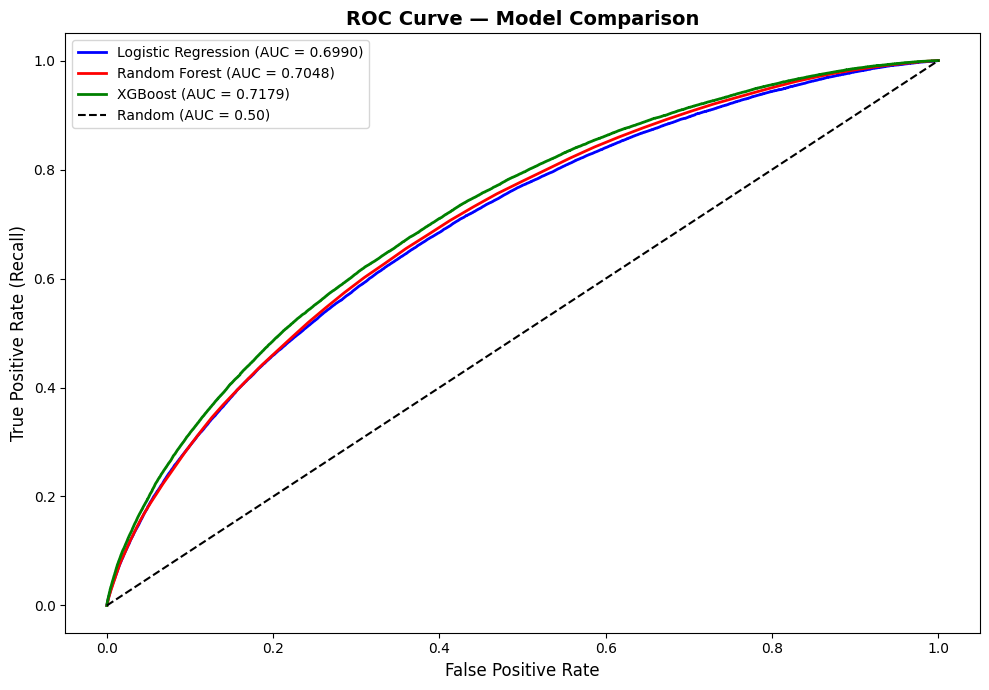

ROC data exported


In [38]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob_lr)
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob_rf)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(10, 7))
plt.plot(lr_fpr, lr_tpr, color='blue', linewidth=2,
         label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})')
plt.plot(rf_fpr, rf_tpr, color='red', linewidth=2,
         label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})')
plt.plot(xgb_fpr, xgb_tpr, color='green', linewidth=2,
         label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random (AUC = 0.50)')
plt.title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('charts/roc_curve_comparison_final.png', dpi=150)
plt.show()

# Export ROC data for Tableau
idx_lr = np.linspace(0, len(lr_fpr)-1, 200).astype(int)
idx_rf = np.linspace(0, len(rf_fpr)-1, 200).astype(int)
idx_xgb = np.linspace(0, len(xgb_fpr)-1, 200).astype(int)

roc_long = pd.DataFrame({
    'fpr': list(xgb_fpr[idx_xgb]) + list(lr_fpr[idx_lr]) + list(rf_fpr[idx_rf]),
    'tpr': list(xgb_tpr[idx_xgb]) + list(lr_tpr[idx_lr]) + list(rf_tpr[idx_rf]),
    'model': ([f'XGBoost ({roc_auc_score(y_test, y_prob_xgb):.4f})'] * 200 +
              [f'Logistic Regression ({roc_auc_score(y_test, y_prob_lr):.4f})'] * 200 +
              [f'Random Forest ({roc_auc_score(y_test, y_prob_rf):.4f})'] * 200)
})
roc_long.to_csv('charts/roc_curves_final.csv', index=False)
print('ROC data exported')

## 8. Feature Importance

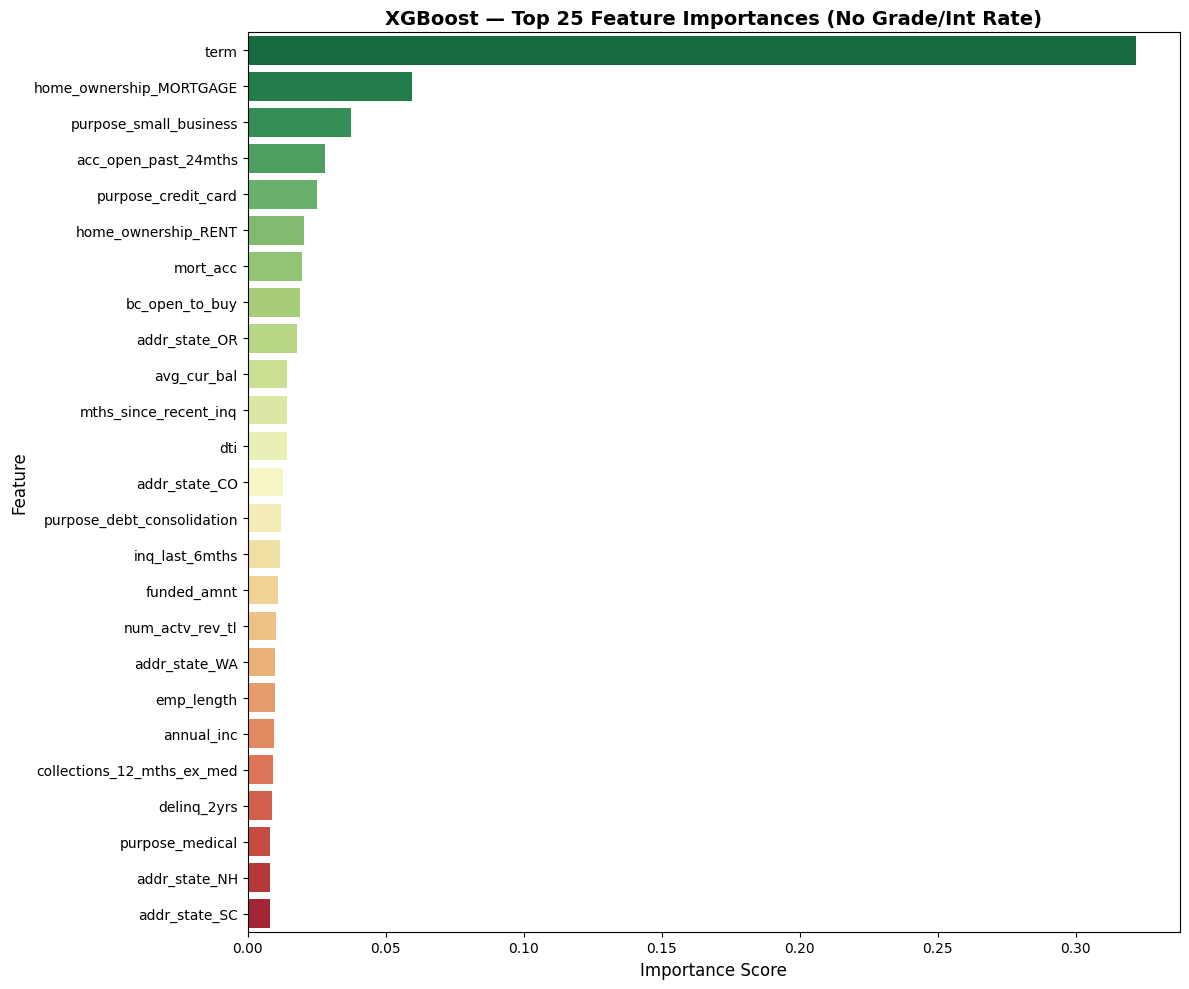

Top 10 features:
                feature  importance
                   term        0.32
home_ownership_MORTGAGE        0.06
 purpose_small_business        0.04
   acc_open_past_24mths        0.03
    purpose_credit_card        0.03
    home_ownership_RENT        0.02
               mort_acc        0.02
         bc_open_to_buy        0.02
          addr_state_OR        0.02
            avg_cur_bal        0.01


In [39]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(12, 10))
sns.barplot(data=importance, x='importance', y='feature',
            hue='feature', palette='RdYlGn_r', legend=False)
plt.title('XGBoost — Top 25 Feature Importances (No Grade/Int Rate)',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('charts/feature_importance_v2.png', dpi=150)
plt.show()

print('Top 10 features:')
print(importance.head(10).to_string(index=False))

## 9. Policy Simulation

Simulates what would have happened if loans above each risk threshold
had been rejected at origination.

In [40]:
# Build test results dataset
test_results = X_test.copy()
test_results['default'] = y_test.values
test_results['default_prob'] = y_prob_xgb

total_loans = len(test_results)
total_defaults = test_results['default'].sum()
baseline_default_rate = test_results['default'].mean()

print(f'Total loans in test set: {total_loans:,}')
print(f'Total defaults: {total_defaults:,}')
print(f'Baseline default rate: {baseline_default_rate:.2%}')

Total loans in test set: 243,485
Total defaults: 49,270.0
Baseline default rate: 20.24%


In [41]:
# Dollar impact assumptions
avg_loan = df['funded_amnt'].mean()
assumed_lgd = 0.70       # 70% loss given default — typical unsecured consumer
assumed_net_yield = 0.05  # 5% net yield on approved loans

print(f'Average loan amount: ${avg_loan:,.0f}')
print(f'Assumed LGD: {assumed_lgd:.0%}')
print(f'Assumed net yield: {assumed_net_yield:.0%}')

thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]

results = []
for threshold in thresholds:
    rejected = test_results[test_results['default_prob'] >= threshold]
    approved = test_results[test_results['default_prob'] < threshold]

    defaults_avoided = rejected['default'].sum()
    loans_rejected = len(rejected)
    defaults_in_approved = approved['default'].sum()
    loss_avoided = defaults_avoided * avg_loan * assumed_lgd
    revenue_lost = (loans_rejected - defaults_avoided) * avg_loan * assumed_net_yield
    net_benefit = loss_avoided - revenue_lost

    results.append({
        'threshold': threshold,
        'loans_rejected': loans_rejected,
        'pct_volume_lost': round(loans_rejected / total_loans * 100, 2),
        'defaults_avoided': defaults_avoided,
        'pct_defaults_avoided': round(defaults_avoided / total_defaults * 100, 2),
        'remaining_default_rate': round(
            defaults_in_approved / len(approved) * 100, 2) if len(approved) > 0 else 0,
        'net_benefit_M': round(net_benefit / 1e6, 1)
    })

sim_df = pd.DataFrame(results)
print(sim_df)

Average loan amount: $14,454
Assumed LGD: 70%
Assumed net yield: 5%


   threshold  loans_rejected  pct_volume_lost  defaults_avoided  \
0       0.50           99322            40.79          32283.00   
1       0.55           78564            32.27          27825.00   
2       0.60           59856            24.58          23138.00   
3       0.65           43150            17.72          18235.00   
4       0.70           29127            11.96          13548.00   
5       0.75           17680             7.26           9019.00   
6       0.80            9042             3.71           5124.00   
7       0.85            3188             1.31           2003.00   

   pct_defaults_avoided  remaining_default_rate  net_benefit_M  
0                 65.52                   11.78         278.20  
1                 56.47                   13.00         244.90  
2                 46.96                   14.23         207.60  
3                 37.01                   15.49         166.50  
4                 27.50                   16.66         125.80  
5     

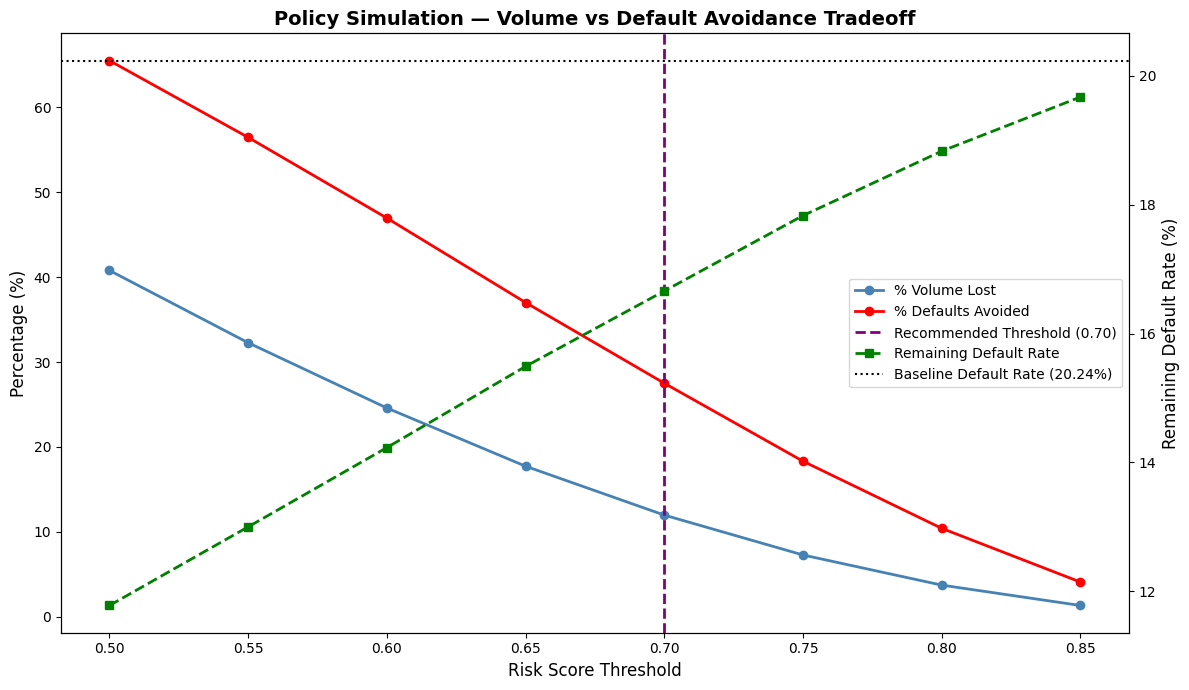

In [42]:
# Policy simulation chart
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(sim_df['threshold'], sim_df['pct_volume_lost'],
         marker='o', color='steelblue', linewidth=2, label='% Volume Lost')
ax1.plot(sim_df['threshold'], sim_df['pct_defaults_avoided'],
         marker='o', color='red', linewidth=2, label='% Defaults Avoided')
ax1.axvline(x=0.70, color='purple', linestyle='--', linewidth=2,
            label='Recommended Threshold (0.70)')
ax1.set_xlabel('Risk Score Threshold', fontsize=12)
ax1.set_ylabel('Percentage (%)', fontsize=12)

ax2 = ax1.twinx()
ax2.plot(sim_df['threshold'], sim_df['remaining_default_rate'],
         marker='s', color='green', linewidth=2, linestyle='--',
         label='Remaining Default Rate')
ax2.axhline(y=baseline_default_rate * 100, color='black',
            linestyle=':', linewidth=1.5,
            label=f'Baseline Default Rate ({baseline_default_rate:.2%})')
ax2.set_ylabel('Remaining Default Rate (%)', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

plt.title('Policy Simulation — Volume vs Default Avoidance Tradeoff',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/policy_simulation_v2_final.png', dpi=150)
plt.show()

## 10. Policy Validation — Term and DTI Rescue Analysis

Testing whether borderline loans (0.70-0.75 threshold) could be salvaged
through term adjustment or DTI-based rescue. Both failed.

In [43]:
# Isolate borderline loans
borderline = test_results[
    (test_results['default_prob'] >= 0.70) &
    (test_results['default_prob'] < 0.75)
].copy()

print(f'Borderline loans (0.70-0.75): {len(borderline):,}')
print(f'Default rate: {borderline["default"].mean():.2%}')

# Split by term
b60 = borderline[borderline['term'] == 60]
b36 = borderline[borderline['term'] == 36]
print(f'\n60-month: {len(b60):,} loans, {b60["default"].mean():.2%} default rate')
print(f'36-month: {len(b36):,} loans, {b36["default"].mean():.2%} default rate')
print('\nFinding: Term has virtually no impact at this risk level')

Borderline loans (0.70-0.75): 11,447
Default rate: 39.56%

60-month: 7,139 loans, 40.33% default rate
36-month: 4,308 loans, 38.30% default rate

Finding: Term has virtually no impact at this risk level


In [44]:
# DTI rescue analysis
approved_base = test_results[test_results['default_prob'] < 0.70]
borderline_all = test_results[test_results['default_prob'] >= 0.70]

borderline_approved = borderline_all[borderline_all['dti'] < 25]
combined_approved = pd.concat([approved_base, borderline_approved])

print('--- Baseline (no policy) ---')
print(f'Default rate: {test_results["default"].mean():.2%}')
print()
print('--- 0.70 threshold only ---')
print(f'Default rate: {approved_base["default"].mean():.2%}')
print(f'Volume rejected: {len(borderline_all)/len(test_results)*100:.1f}%')
print()
print('--- 0.70 threshold + DTI < 25 rescue ---')
print(f'Default rate: {combined_approved["default"].mean():.2%}')
print(f'Volume rejected: {(len(test_results)-len(combined_approved))/len(test_results)*100:.1f}%')
print(f'Rescued loans default at: {borderline_approved["default"].mean():.2%}')
print()
print('Finding: DTI rescue counterproductive — rescued loans default at ~45%')
print('Conclusion: 0.70 threshold is the optimal policy instrument')

--- Baseline (no policy) ---
Default rate: 20.24%

--- 0.70 threshold only ---
Default rate: 16.66%
Volume rejected: 12.0%

--- 0.70 threshold + DTI < 25 rescue ---
Default rate: 18.71%
Volume rejected: 5.1%
Rescued loans default at: 45.12%

Finding: DTI rescue counterproductive — rescued loans default at ~45%
Conclusion: 0.70 threshold is the optimal policy instrument


## 11. Export for Tableau

In [46]:
# Build Tableau-friendly dataset with original categorical columns
tableau_df = df.loc[X_test.index, [
    'funded_amnt', 'term', 'dti', 'annual_inc', 'emp_length',
    'home_ownership', 'purpose', 'addr_state', 'bc_util',
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'pub_rec',
    'acc_open_past_24mths', 'credit_age_months',
    'mths_since_last_delinq', 'default',
    'grade', 'int_rate'  # included for Tableau context only — not model features
]].copy()

tableau_df['default_prob'] = y_prob_xgb

tableau_df['risk_tier'] = pd.cut(
    tableau_df['default_prob'],
    bins=[0, 0.50, 0.60, 0.70, 0.80, 1.0],
    labels=['Low (0-50)', 'Moderate (50-60)',
            'Elevated (60-70)', 'High (70-80)', 'Very High (80+)']
)

tableau_df.to_csv('lending_club_tableau.csv', index=False)
print('Tableau export saved')
print('Shape:', tableau_df.shape)

Tableau export saved
Shape: (243485, 21)


## Summary

| Model | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.32 | 0.63 | 0.42 | 0.6990 |
| Random Forest | 0.45 | 0.24 | 0.31 | 0.7048 |
| **XGBoost (selected)** | **0.33** | **0.66** | **0.43** | **0.7179** |

**Selected model:** XGBoost — highest AUC and recall

**Recommended threshold: 0.70**
- Reject 11.96% of volume
- Avoid 27.50% of defaults
- Reduce default rate from 20.24% to 16.66%
- Estimated net benefit: $125.8M

*Dollar figures illustrative — assumed LGD 70%, net yield 5%*